# IPL Data Analysis & Visualization Lab

## Learning Outcomes
By the end of this session, you will be able to:

- Load and inspect real-world datasets
- Perform aggregation using groupby()
- Extract Top-N records
- Create bar, scatter, histogram, box and pie charts
- Create derived logical columns
- Use documentation to extend functionality
- Build a performance story using visualization

Workflow:
Load → Inspect → Aggregate → Visualize → Interpret

## dataset: https://github.com/12345k/IPL-Dataset/blob/master/IPL/data.csv

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

df = pd.read_csv("ipl_full_matches.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Q1. Load and Inspect Dataset

1. Display first 10 records.
2. Print:
   - Total rows
   - Total columns
   - Data types
3. Identify:
   - Numerical columns
   - Categorical columns
4. Check for missing values.

In [4]:
df.head(10)

,id,season,city,date,team1,team2,toss_winner,toss_decision,winner,venue,result,result_margin,player_of_match
0,1,2008,Chepauk,2008-04-01,GT,SRH,GT,bat,SRH,Chepauk Stadium,normal,19,Player_192
1,2,2008,Wankhede,2008-04-02,KKR,PBKS,PBKS,bat,KKR,Wankhede Stadium,normal,13,Player_151
2,3,2008,Chepauk,2008-04-03,PBKS,RR,PBKS,bat,RR,Chepauk Stadium,normal,15,Player_120
3,4,2008,Chinnaswamy,2008-04-04,RCB,MI,MI,bat,MI,Chinnaswamy Stadium,normal,9,Player_83
4,5,2008,Narendra,2008-04-05,KKR,PBKS,PBKS,bat,PBKS,Narendra Modi Stadium,normal,20,Player_2
5,6,2008,Rajiv,2008-04-06,KKR,RCB,KKR,bat,KKR,Rajiv Gandhi Stadium,normal,8,Player_136
6,7,2008,Narendra,2008-04-07,GT,RR,RR,bat,RR,Narendra Modi Stadium,normal,30,Player_171
7,8,2008,Chepauk,2008-04-08,LSG,MI,LSG,field,LSG,Chepauk Stadium,normal,17,Player_198
8,9,2008,Arun,2008-04-09,PBKS,SRH,PBKS,bat,SRH,Arun Jaitley Stadium,normal,37,Player_121
9,10,2008,Wankhede,2008-04-10,GT,PBKS,PBKS,bat,GT,Wankhede Stadium,normal,20,Player_101


In [5]:
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nData Types:")
print(df.dtypes)

Total Rows: 560
Total Columns: 13

Data Types:
id                  int64
season              int64
city               object
date               object
team1              object
team2              object
toss_winner        object
toss_decision      object
winner             object
venue              object
result             object
result_margin       int64
player_of_match    object
dtype: object


In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(list(numerical_cols))
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("\nCategorical Columns:")
print(list(categorical_cols))

Numerical Columns:
['id', 'season', 'result_margin']

Categorical Columns:
['city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'venue', 'result', 'player_of_match']


In [11]:
print(df.isnull().sum().sum())

0


## Q2. Structural Overview

Find:
- Total matches
- Total unique teams
- Total seasons
- Total venues

In [12]:
print("Total Matches:", df.shape[0])

Total Matches: 560


In [19]:
print("Total teams:", df['team1'].nunique())

Total teams: 10


In [20]:
print("Total season:",df['season'].nunique())

Total season: 16


In [21]:
print("Total venue:",df['venue'].nunique())

Total venue: 7


## Q3. Matches per Season

1. Compute matches played per season.
2. Plot using Matplotlib.
3. Identify:
   - Season with maximum matches
   - Season with minimum matches

In [24]:
matches_persea=df.groupby('season')['id'].nunique()
print(matches_persea)

season
2008    35
2009    35
2010    35
2011    35
2012    35
2013    35
2014    35
2015    35
2016    35
2017    35
2018    35
2019    35
2020    35
2021    35
2022    35
2023    35
Name: id, dtype: int64


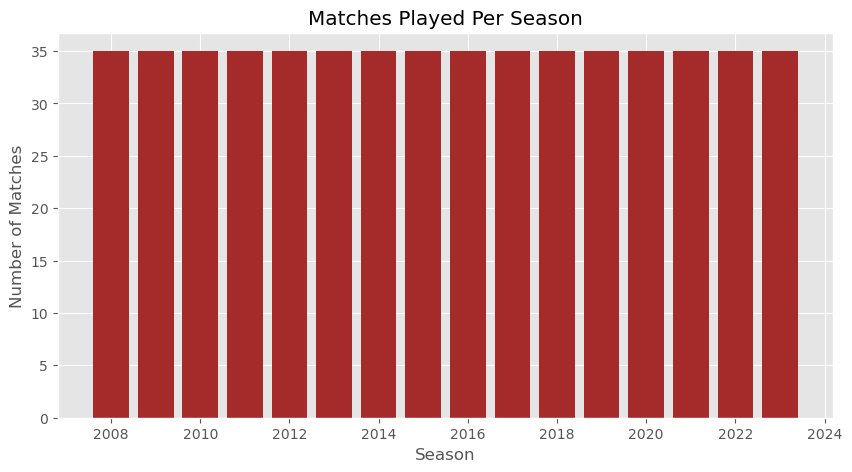

In [81]:
plt.figure(figsize=(10,5))
plt.bar(matches_persea.index, matches_persea.values, color='brown')
plt.title("Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()

In [26]:
max_season=matches_persea.idxmax()
max_matches=matches_persea.max()
print("season with maximum matches:",max_season)
print("Number of matches",max_matches)

season with maximum matches: 2008
Number of matches 35


## Q4. Top 5 Teams with Most Wins

1. Find top 5 teams.
2. Plot using Seaborn.
3. Add value labels.

In [39]:
top5=df["winner"].value_counts().head()
print(top5)

DC      73
PBKS    65
SRH     60
LSG     57
CSK     56
Name: winner, dtype: int64


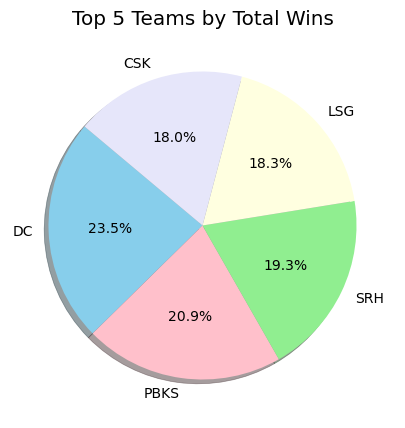

In [56]:
plt.figure(figsize=(8,5))
plt.pie(
    top5.values,
    labels=top5.index,
    autopct='%1.1f%%', 
    startangle=140,
    colors=["skyblue","pink","lightgreen","lightyellow","lavender"],
    shadow=True
)

plt.title("Top 5 Teams by Total Wins")
plt.show()

## Q5. Top 10 “Player of the Match” Award Winners

In this question, you will analyze individual player impact using the  
`player_of_match` column.

### Tasks:

1. Identify the **Top 10 players** who have received the highest number of  
   *Player of the Match* awards.
2. Sort the values properly in descending order.
3. Create a **horizontal bar plot** to visualize the Top 10 players.
4. Add the following to improve readability:
   - Clear title
   - X-axis and Y-axis labels
   - Grid lines
5. Write 2–3 lines interpreting the result:
   - Who appears most dominant?
   - Is there a large gap between top players?

### Hint:
- Use `value_counts()` or `groupby()` appropriately.
- Consider using `plt.barh()` for better readability when labels are long.
- Use `plt.gca().invert_yaxis()` to display the highest value at the top.


In [45]:
top10=df["player_of_match"].value_counts().head(10)
print(top10)

Player_69     8
Player_171    7
Player_71     7
Player_156    7
Player_83     6
Player_82     6
Player_4      6
Player_70     6
Player_3      6
Player_176    6
Name: player_of_match, dtype: int64


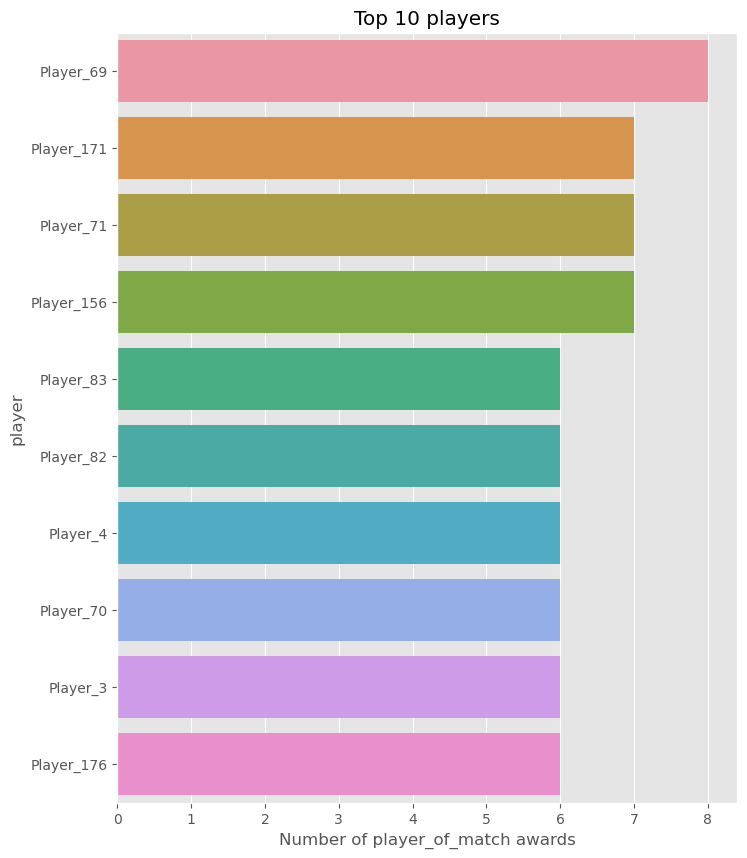

In [49]:
plt.figure(figsize=(8,10))
ax = sns.barplot(
    x=top10.values,
    y=top10.index,
)
plt.title("Top 10 players")
plt.xlabel("Number of player_of_match awards")
plt.ylabel("player")
plt.style.use("ggplot")

## Q6. Home vs Away Wins

1. Create derived column:
   home_win = winner == team1
2. Compute totals.
3. Plot comparison.

In [67]:
df["home_win"]=df["winner"]==df["team1"]
print(df["home_win"].head())

0    False
1     True
2    False
3    False
4    False
Name: home_win, dtype: bool


In [101]:
total=df["home_win"].value_counts()
print(total)
print("Total number of times team1 won:",total[True])
print("Total number of times team2 won:",total[False])
total.index=["Team1","Team2"]

False    299
True     261
Name: home_win, dtype: int64
Total number of times team1 won: 261
Total number of times team2 won: 299


In [102]:
print(total.index)
print(total.values)

Index(['Team1', 'Team2'], dtype='object')
[299 261]


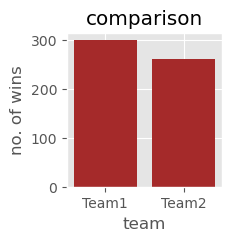

In [103]:
plt.figure(figsize=(2,2))
plt.bar(total.index, total.values, color='brown')
plt.title("comparison")
plt.xlabel("team")
plt.ylabel("no. of wins")
plt.show()

## Q7. Wins by Venue

1. Identify top 5 venues.
2. Plot pie chart.
3. Add percentage labels.

In [57]:
top5v=df["venue"].value_counts().head()
print(top5v)

Arun Jaitley Stadium     88
Narendra Modi Stadium    87
Rajiv Gandhi Stadium     86
Wankhede Stadium         80
Chepauk Stadium          78
Name: venue, dtype: int64


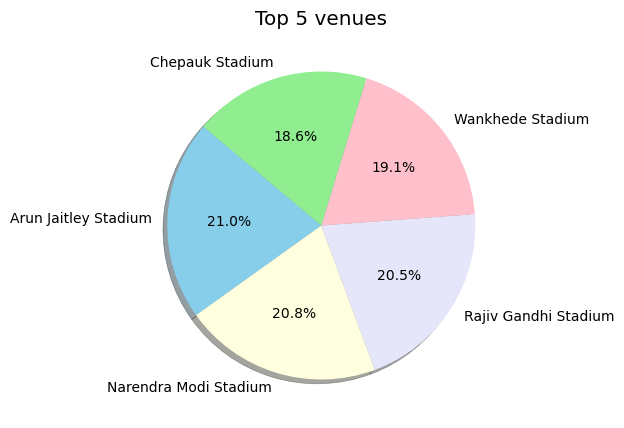

In [61]:
plt.figure(figsize=(8,5))
plt.pie(
    top5v.values,
    labels=top5v.index,
    autopct='%1.1f%%', 
    startangle=140,
    colors=["skyblue","lightyellow","lavender","pink","lightgreen"],
    shadow=True
)

plt.title("Top 5 venues")
plt.show()

## Q8. Performance Story

Create a visualization that explains one performance trend.
Add:
- Title
- Annotation
- Interpretation

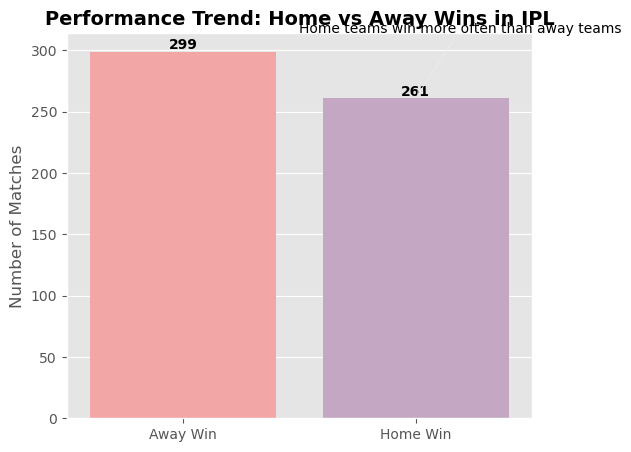

In [104]:

# Derived column: home_win
df['home_win'] = df['winner'] == df['team1']

# Count total home vs away wins
win_counts = df['home_win'].value_counts()
win_counts.index = ['Away Win', 'Home Win']  # rename for clarity
plt.figure(figsize=(6,5))
sns.barplot(x=win_counts.index, y=win_counts.values, palette=['#ff9999','#c8a2c8'])

# Add value labels
for i, v in enumerate(win_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

# Title
plt.title("Performance Trend: Home vs Away Wins in IPL", fontsize=14, fontweight='bold')

# Annotation
plt.annotate(
    "Home teams win more often than away teams",
    xy=(1, win_counts['Home Win']), xycoords='data',
    xytext=(0.5, win_counts.max() + 15), textcoords='data',
    arrowprops=dict(facecolor='black', arrowstyle="->"),
    fontsize=10, fontweight='medium'
)

plt.ylabel("Number of Matches")
plt.show()

## Q9. Documentation Task – Matplotlib

Visit:
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

Modify your Top Teams plot to:
- Change bar width
- Add custom color
- Add legend
- Rotate labels

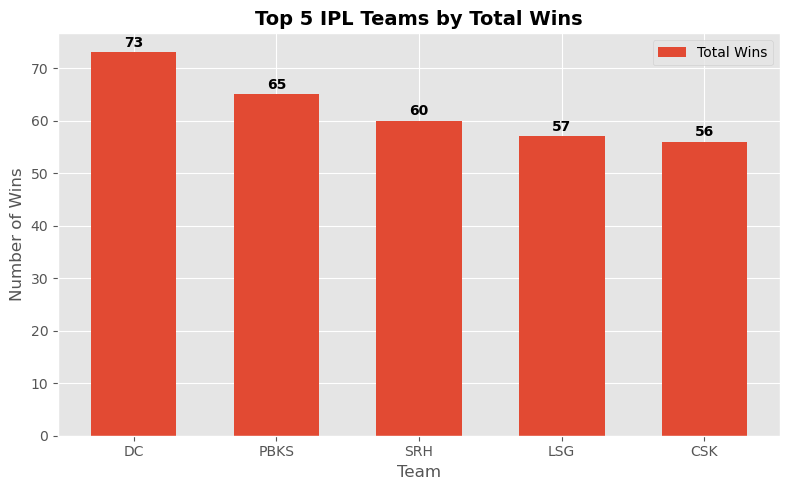

In [108]:
top_5_teams = df['winner'].value_counts().head(5)
teams = top_5_teams.index
wins = top_5_teams.values
plt.figure(figsize=(8,5))
bars = plt.bar(
    teams,
    wins,
    width=0.6,  # Change bar width
    label='Total Wins'
)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', fontweight='bold')
plt.title("Top 5 IPL Teams by Total Wins", fontsize=14, fontweight='bold')
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.legend()

plt.tight_layout()
plt.show()

## Q10. Documentation Task – Pandas GroupBy

Visit:
https://pandas.pydata.org/docs/reference/groupby.html

Using agg():

1. Compute:
   - Total matches per team
   - Total wins per team
   - Win percentage
2. Identify team with highest win percentage.

In [109]:
matches_played = pd.concat([df['team1'], df['team2']]).value_counts().sort_index()
matches_played = matches_played.reset_index()
matches_played.columns = ['team', 'total_matches']
wins = df['winner'].value_counts().sort_index().reset_index()
wins.columns = ['team', 'total_wins']
team_stats = pd.merge(matches_played, wins, on='team', how='left')
team_stats['total_wins'] = team_stats['total_wins'].fillna(0)  # Some teams may have 0 wins
team_stats['win_percentage'] = (team_stats['total_wins'] / team_stats['total_matches']) * 100

team_stats = team_stats.sort_values(by='win_percentage', ascending=False)
team_stats
top_team = team_stats.iloc[0]
print(f"Team with Highest Win Percentage: {top_team['team']}")
print(f"Win Percentage: {top_team['win_percentage']:.2f}%")
print(f"Total Matches: {int(top_team['total_matches'])}, Total Wins: {int(top_team['total_wins'])}")

Team with Highest Win Percentage: DC
Win Percentage: 59.84%
Total Matches: 122, Total Wins: 73


## Q11. Reflection

Write 3 insights from your analysis:

1. _____________
2. _____________
3. _____________